In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('TMDB/movies_metadata.csv', low_memory=False)
print(f"Raw data: {df.shape}")

for col in ['budget', 'revenue', 'runtime', 'popularity', 'vote_count']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df[df['budget'].notna() & df['revenue'].notna()]
df = df[df['budget'] > 0]
df = df[df['revenue'] > 0]

print(f"After filtering: {df.shape}")


Raw data: (45466, 24)
After filtering: (5381, 24)


In [9]:
# Features, ROI, and balanced sample
FEATURES = ["budget", "runtime", "popularity", "vote_count"]

df["roi"] = df["revenue"] / df["budget"]

df_sample = (
    df.groupby((df["roi"] >= 2.5).astype(int), group_keys=False)
      .apply(lambda x: x.sample(n=min(len(x), 15000), random_state=42))
)

print(df_sample.shape)


(5381, 25)


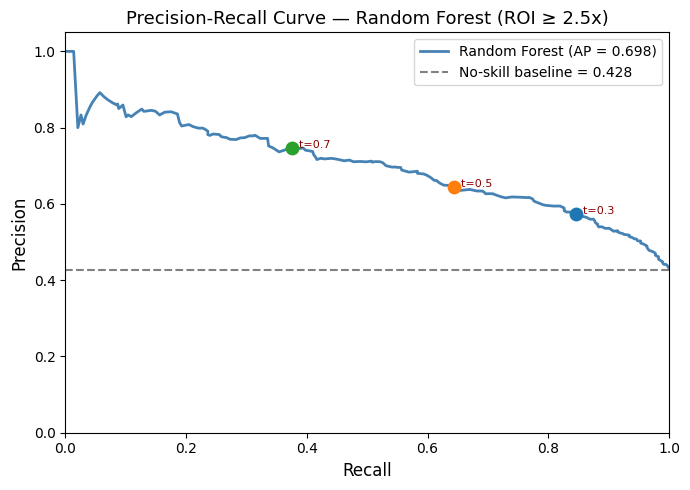

Average Precision (AP): 0.6981
No-skill baseline:      0.4279


In [10]:
# PRECISION-RECALL CURVE
# Model: Random Forest
# Threshold: ROI >= 2.5
# Self-contained: rebuilds train/test split and RF from scratch

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# --- Rebuild data (mirrors Cell 19 exactly) ---
_thr = 2.5
_tmp = df_sample.copy()
_tmp['profitable'] = (_tmp['roi'] >= _thr).astype(int)

_X = _tmp[FEATURES].fillna(_tmp[FEATURES].median())
_y = _tmp['profitable']

_X_train, _X_test, _y_train, _y_test = train_test_split(
    _X, _y, test_size=0.25, random_state=42, stratify=_y
)

_rf = RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    n_jobs=-1,
    class_weight='balanced_subsample'
)
_rf.fit(_X_train, _y_train)
_probs = _rf.predict_proba(_X_test)[:, 1]

# --- Precision-Recall Curve ---
precision, recall, thresholds = precision_recall_curve(_y_test, _probs)
avg_precision = average_precision_score(_y_test, _probs)
baseline = _y_test.mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='steelblue', lw=2,
        label=f'Random Forest (AP = {avg_precision:.3f})')
ax.axhline(y=baseline, color='gray', linestyle='--', lw=1.5,
           label=f'No-skill baseline = {baseline:.3f}')

# Mark and annotate key threshold values
for thr_val in [0.3, 0.5, 0.7]:
    idx = np.argmin(np.abs(thresholds - thr_val))
    ax.scatter(recall[idx], precision[idx], s=80, zorder=5)
    ax.annotate(f'  t={thr_val}',
                xy=(recall[idx], precision[idx]),
                fontsize=8, color='darkred')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Random Forest (ROI ≥ 2.5x)', fontsize=13)
ax.legend(loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('01_precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Average Precision (AP): {avg_precision:.4f}')
print(f'No-skill baseline:      {baseline:.4f}')


In [11]:
# THRESHOLD COMPARISON TABLE
# Precision, Recall, F1 at various decision thresholds
# Depends on _probs and _y_test from the PR curve cell above

import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

rows = []
for thr_val in np.arange(0.2, 0.85, 0.05):
    preds = (_probs >= thr_val).astype(int)
    rows.append({
        'Threshold': round(thr_val, 2),
        'Precision': round(precision_score(_y_test, preds, zero_division=0), 3),
        'Recall':    round(recall_score(_y_test, preds, zero_division=0), 3),
        'F1':        round(f1_score(_y_test, preds, zero_division=0), 3),
    })

thr_df = pd.DataFrame(rows)
display(thr_df)


,Threshold,Precision,Recall,F1
0,0.20,0.530,0.915,0.671
1,0.25,0.550,0.878,0.676
2,0.30,0.573,0.845,0.683
3,0.35,0.594,0.809,0.685
4,0.40,0.616,0.767,0.684
5,0.45,0.627,0.703,0.663
6,0.50,0.645,0.644,0.645
7,0.55,0.686,0.583,0.630
8,0.60,0.711,0.521,0.601
9,0.65,0.720,0.441,0.547


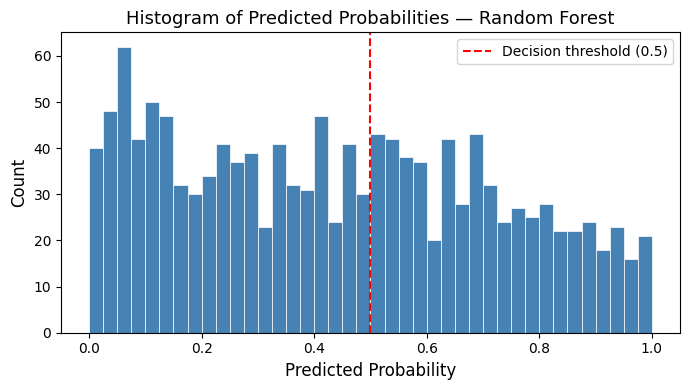

In [12]:
# PROBABILITY CALIBRATION CHECK
# Model: Random Forest
# Threshold: ROI >= 2.5

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(_probs, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
ax.set_xlabel('Predicted Probability', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Histogram of Predicted Probabilities — Random Forest', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

### Calibration Interpretation

A well-calibrated model produces predicted probabilities spread across the full 0–1 range, reflecting genuine uncertainty. If the histogram shows most predictions clustered near 0 or 1 with little mass in between, the model is overconfident so it's committing strongly to outcomes rather than expressing uncertainty proportional to the actual difficulty of each prediction. Random Forests are known to exhibit this tendency because they output class proportions averaged across many trees, which tends to push probabilities toward the extremes, particularly when trees agree. If the histogram here shows heavy concentration at the tails, techniques like Platt scaling or isotonic regression can be applied post-hoc to bring the probabilities closer to their true likelihoods without retraining the model.

## Threshold Tradeoff Discussion

The precision-recall curve reveals a classic inverse relationship between precision and recall as the decision threshold is varied. At lower thresholds (e.g., 0.20–0.30), the Random Forest casts a wide net and flags many movies as highly profitable (ROI ≥ 2.5×), achieving high recall — meaning it misses fewer genuinely profitable films — but at the cost of precision, since many false positives (non-profitable films incorrectly labeled profitable) are included. Conversely, raising the threshold toward 0.70+ sharply increases precision — nearly every movie flagged as profitable truly is — but recall collapses, leaving a large share of actual profitable films undetected. The default threshold of 0.50 sits near the "knee" of the curve and provides a reasonable balance as reflected in the F1 scores, though the optimal operating point depends heavily on business context: a studio allocating a fixed greenlight budget where backing a flop is costly should favor higher thresholds to protect precision, while an investment screener that cannot afford to miss breakout hits should lower the threshold to maximize recall, accepting more false alarms in exchange for broader coverage of genuinely profitable opportunities.

Changes from relevant code in Andrew's Baseline Notebook:

Data loading (Cell 0): The original read from ../data/raw/TMDB_movie_dataset_v11.csv using pathlib Path objects and only coerced budget and revenue to numeric. The new notebook reads from TMDB/movies_metadata.csv to match the shared dataset location, and explicitly coerces all five feature columns (budget, revenue, runtime, popularity, vote_count) to numeric upfront — the extra coercions were necessary because movies_metadata.csv stores some of those as strings.
Sampling (Cell 6 removed): The original downsampled to 200k rows, which was needed for the larger dataset. This was dropped entirely since movies_metadata.csv is already well under that size.
Target variable: The original notebook modeled high_rating (vote average ≥ 7). The new notebook models profitable (ROI ≥ 2.5×), which was the target used in the Random Forest cells later in the original — those are the cells the PR curve work is based on.
Everything else — the balanced df_sample construction, RF parameters, train/test split, and all PR curve code — is new and has no direct equivalent in the original.